# Authors
- Raphael Wäspi (18-918-938)
- Nicolas Huber (16-936-205)

In [353]:
import math
# Imports
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os
import glob
import re
import random
import multiprocessing
from statistics import mean

import scipy.special
from tqdm import tqdm
import shutil
from joblib import Parallel, delayed
from scipy.special import factorial
import powerlaw
from NEMtropy import DirectedGraph, UndirectedGraph
from NEMtropy import matrix_generator as mg
from NEMtropy.network_functions import build_adjacency_from_edgelist


In [354]:
# Define colors with reduced opacity from a colormap
COLOR_BLUE = 'dodgerblue'
COLOR_GREEN = 'palegreen'
COLOR_RED = 'lightcoral'
COLOR_YELLOW = 'gold'
COLOR_GREY = 'slategrey'
COLOR_BLACK = 'black'
COLOR_LIGHT_GRAY = 'lightgray'
COLOR_DARK_GRAY = 'darkgray'

# Define the main data directory
OUTPUT_PATH = "./output"

In [355]:
# Set Seed
SEED = 42

In [356]:
# Prepare output folder

# Delete the entire 'output' directory and its contents
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

# Create the 'output' directory
os.makedirs(OUTPUT_PATH)

# Define subdirectories
OUTPUT_PATH_ERGMS = os.path.join(OUTPUT_PATH, "ERGMs")


# Recreate the subdirectories
os.makedirs(OUTPUT_PATH_ERGMS)

In [357]:
# Define the directory containing the .gml files
directory = 'assignment_03_data'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.gml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()
            
            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.gml$', file_path)
            if match:
                graph_name = match.group(1)
                
                # Add to the graph dictionary
                graph = nx.read_gml(file_path)
                graphs[graph_name] = graph
                
                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")
                
        pbar.update(1)  # Update the progress bar

Loading GML Files:  50%|█████     | 1/2 [00:00<00:00,  4.18it/s]

Finished loading graph_eu_airlines


Loading GML Files: 100%|██████████| 2/2 [00:00<00:00,  2.60it/s]

Finished loading graph_power


In [358]:
# Define the directory containing the .gml files
directory = 'assignment_03_data/World_Trade_Web'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.graphml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs_wtn = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML WTW Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()

            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.txt.graphml$', file_path)
            if match:
                graph_name = match.group(1)

                # Add to the graph dictionary
                graph = nx.read_graphml(file_path)
                graphs_wtn[graph_name] = graph

                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")

        pbar.update(1)  # Update the progress bar

Loading GML WTW Files:   9%|▉         | 1/11 [00:02<00:23,  2.39s/it]

Finished loading WDN_1997
Finished loading WDN_1992


Loading GML WTW Files:  36%|███▋      | 4/11 [00:03<00:04,  1.50it/s]

Finished loading WDN_2000
Finished loading WDN_1998


Loading GML WTW Files:  45%|████▌     | 5/11 [00:03<00:02,  2.01it/s]

...

Finished loading WDN_1993
Finished loading WDN_2002


Loading GML WTW Files:  82%|████████▏ | 9/11 [00:05<00:00,  2.53it/s]

Finished loading WDN_1996
Finished loading WDN_1995


Loading GML WTW Files: 100%|██████████| 11/11 [00:06<00:00,  1.81it/s]

Finished loading WDN_1999
Finished loading WDN_2001


# I ERGMs

In [359]:
graphs

{'graph_eu_airlines': <networkx.classes.graph.Graph at 0x16bf176d0>,
 'graph_power': <networkx.classes.graph.Graph at 0x16c96ff90>}

In [360]:
graphs_wtn

{'WDN_1997': <networkx.classes.digraph.DiGraph at 0x163710cd0>,
 'WDN_1992': <networkx.classes.digraph.DiGraph at 0x16ba32510>,
 'WDN_2000': <networkx.classes.digraph.DiGraph at 0x16035dd50>,
 'WDN_1998': <networkx.classes.digraph.DiGraph at 0x165ae6fd0>,
 'WDN_1994': <networkx.classes.digraph.DiGraph at 0x16c77e610>,
 'WDN_1993': <networkx.classes.digraph.DiGraph at 0x169b26990>,
 'WDN_2002': <networkx.classes.digraph.DiGraph at 0x166855e90>,
 'WDN_1996': <networkx.classes.digraph.DiGraph at 0x167748850>,
 'WDN_1995': <networkx.classes.digraph.DiGraph at 0x16d2f9f10>,
 'WDN_1999': <networkx.classes.digraph.DiGraph at 0x1671fad50>,
 'WDN_2001': <networkx.classes.digraph.DiGraph at 0x16d579990>}

## 1. Compute the strength assortativity coefficient on the data.
Hint: Pay attention: the underlying data (WTW) are weighted and direted, meaning you should account
for four different kind of assortativity: in–in, in–out, out–in, out–out.

In [361]:
def calculate_assortativity(graph):
    in_in = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='in', y='in', weight='weight')
    in_out = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='in', y='out', weight='weight')
    out_in = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='out', y='in', weight='weight')
    out_out = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='out', y='out', weight='weight')

    # Create a dictionary to store assortativity values
    assortativity_dict = {
        "In-In Assortativity": in_in,
        "In-Out Assortativity": in_out,
        "Out-In Assortativity": out_in,
        "Out-Out Assortativity": out_out
    }

    # Return dictionary with assortativity values
    return assortativity_dict

In [362]:
assortativities = {}
for graph_name, graph in graphs_wtn.items():
    assortativities[graph_name] = calculate_assortativity(graph=graph)
    
print(assortativities)

{'WDN_1997': {'In-In Assortativity': -0.073686352073877, 'In-Out Assortativity': -0.07132955497657789, 'Out-In Assortativity': -0.07171683897072376, 'Out-Out Assortativity': -0.069700798720094}, 'WDN_1992': {'In-In Assortativity': -0.04868776409103533, 'In-Out Assortativity': -0.04664740434092386, 'Out-In Assortativity': -0.059869793086991335, 'Out-Out Assortativity': -0.05760318920541264}, 'WDN_2000': {'In-In Assortativity': -0.0631970717497539, 'In-Out Assortativity': -0.06467170213846347, 'Out-In Assortativity': -0.06539073425903166, 'Out-Out Assortativity': -0.06730072607061889}, 'WDN_1998': {'In-In Assortativity': -0.06557057818395721, 'In-Out Assortativity': -0.06540616504184192, 'Out-In Assortativity': -0.06572057397949528, 'Out-Out Assortativity': -0.06583617855060356}, 'WDN_1994': {'In-In Assortativity': -0.07868988970611884, 'In-Out Assortativity': -0.07622523439269807, 'Out-In Assortativity': -0.0802250161794805, 'Out-Out Assortativity': -0.07800143058821393}, 'WDN_1993': {'

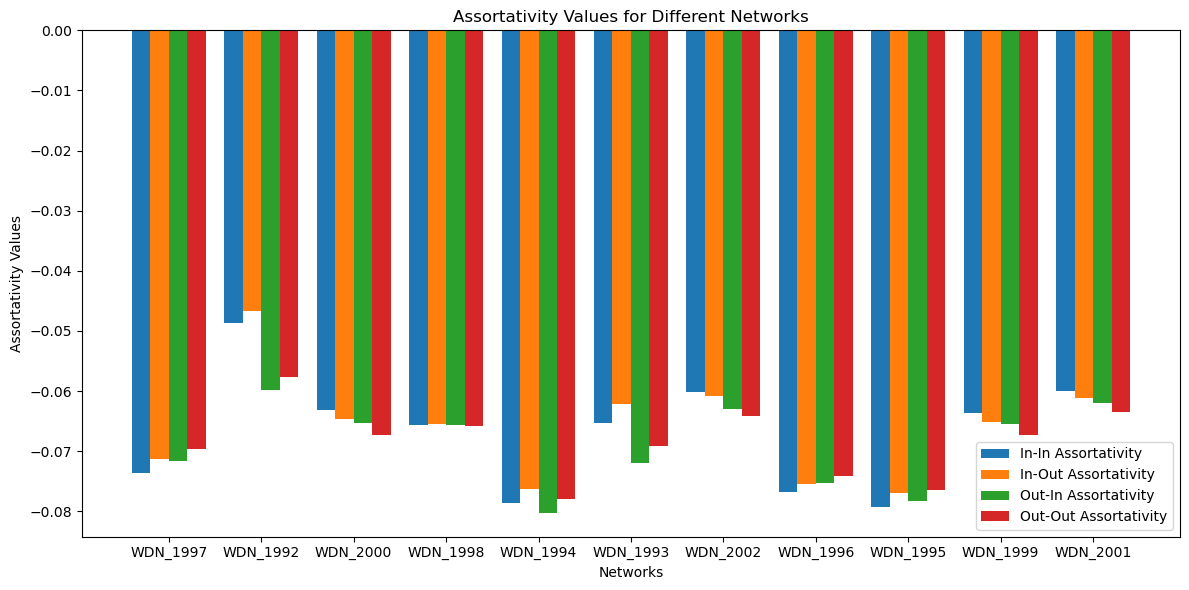

In [363]:
# Extracting graph names and assortativity values
graph_names = list(assortativities.keys())
keys = list(assortativities[graph_names[0]].keys())  # Extracting keys for assortativity values
values = {graph_name: [assortativities[graph_name][key] for key in keys] for graph_name in graph_names}

# Creating side-by-side bar plots for each network
bar_width = 0.2  # Width of each bar
index = np.arange(len(graph_names))  # Index for the networks

plt.figure(figsize=(12, 6))

for i, key in enumerate(keys):
    plt.bar(index + (i * bar_width), [values[graph_name][i] for graph_name in graph_names], bar_width, label=key)

plt.xlabel('Networks')
plt.ylabel('Assortativity Values')
plt.title('Assortativity Values for Different Networks')
plt.xticks(index + (bar_width * (len(keys) - 1) / 2), graph_names)
plt.legend()
plt.tight_layout()

plt.show()

## 2. Fit the Undirected Enhanced CM and Directed Enhanced CM using the CReMa method.
Hint: You can use the nemtropy package on networkx to deploy these methods. You can find some examples
at https://github.com/nicoloval/NEMtropy/blob/master/examples/Directed%20Graphs.
ipynb. For additional questions, do not hesitate to ask at the QA.

In [364]:
# Create undirected versions of the graph

graphs_wtn_undirected = {}
for graph_name, graph in graphs_wtn.items():
    graph_undirected = graph.to_undirected()

    graphs_wtn_undirected[graph_name] = graph_undirected

In [365]:
FIG_SIZE = (16, 12)
NODE_SIZE = 100
MAX_STEPS = 100

In [366]:
graphs_wtn

{'WDN_1997': <networkx.classes.digraph.DiGraph at 0x163710cd0>,
 'WDN_1992': <networkx.classes.digraph.DiGraph at 0x16ba32510>,
 'WDN_2000': <networkx.classes.digraph.DiGraph at 0x16035dd50>,
 'WDN_1998': <networkx.classes.digraph.DiGraph at 0x165ae6fd0>,
 'WDN_1994': <networkx.classes.digraph.DiGraph at 0x16c77e610>,
 'WDN_1993': <networkx.classes.digraph.DiGraph at 0x169b26990>,
 'WDN_2002': <networkx.classes.digraph.DiGraph at 0x166855e90>,
 'WDN_1996': <networkx.classes.digraph.DiGraph at 0x167748850>,
 'WDN_1995': <networkx.classes.digraph.DiGraph at 0x16d2f9f10>,
 'WDN_1999': <networkx.classes.digraph.DiGraph at 0x1671fad50>,
 'WDN_2001': <networkx.classes.digraph.DiGraph at 0x16d579990>}

In [367]:
graphs_wtn_undirected

{'WDN_1997': <networkx.classes.graph.Graph at 0x16dd74190>,
 'WDN_1992': <networkx.classes.graph.Graph at 0x16c1c7e50>,
 'WDN_2000': <networkx.classes.graph.Graph at 0x16725ad90>,
 'WDN_1998': <networkx.classes.graph.Graph at 0x166882090>,
 'WDN_1994': <networkx.classes.graph.Graph at 0x16ddab3d0>,
 'WDN_1993': <networkx.classes.graph.Graph at 0x166f9a950>,
 'WDN_2002': <networkx.classes.graph.Graph at 0x166f7d150>,
 'WDN_1996': <networkx.classes.graph.Graph at 0x167328450>,
 'WDN_1995': <networkx.classes.graph.Graph at 0x16074d290>,
 'WDN_1999': <networkx.classes.graph.Graph at 0x163c2d950>,
 'WDN_2001': <networkx.classes.graph.Graph at 0x169c46fd0>}

In [368]:
nemtropy_directed_results = {}
nemtropy_undirected_results = {}

In [369]:
def to_entropy_graph(graph):
    # Extract necessary information from the NetworkX graph
    adj_weigh = nx.to_numpy_array(graph)  # Adjacency matrix
    edges = list(graph.edges())  # Edge list
    degrees = dict(graph.degree())  # Degree sequence (as a dictionary)
    strengths = dict(graph.degree(weight='weight'))  # Strength sequence (assuming weights are present)
    
    return adj_weigh, edges, degrees, strengths

In [370]:
def to_networkx_graph(adj_weigh):
    graph = nx.from_numpy_array(adj_weigh, create_using=nx.DiGraph)

    # Set edge attributes (weights) from the adjacency matrix
    edges = graph.edges(data=True)
    for (u, v, d) in edges:
        d['weight'] = adj_weigh[u][v]
    return graph

In [371]:
def plot_networkx(graph, graph_name, is_directed):

    # Plot the graph
    plt.figure(figsize=FIG_SIZE)

    # Set the layout for consistent plotting
    pos = nx.kamada_kawai_layout(graph)

    # Draw nodes and labels
    nx.draw(graph, pos, with_labels=True, node_size=NODE_SIZE, node_color='skyblue', font_weight='bold')

    # Draw edge labels with weights
    edge_labels = nx.get_edge_attributes(graph, 'weight')
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels)

    plt.title(f'{ "Undirected" if not is_directed else "Directed" } Weighted Graph of Network {graph_name} (networkx plot)')
    file_name=f'{ "undirected_" if not is_directed else "directed_"}weighted_graph_{graph_name}_networkx.png'
    complete_plot_filename=os.path.join(OUTPUT_PATH_ERGMS, file_name)
    plt.savefig(complete_plot_filename)
    plt.show()

In [372]:
def plot_entropy_graph(adj_weigh, graph_name, is_directed):
    # Create a NetworkX graph from the weighted adjacency matrix
    graph = nx.from_numpy_array(adj_weigh, create_using=nx.DiGraph)

    # Set edge attributes (weights) from the adjacency matrix
    edges = graph.edges(data=True)
    for (u, v, d) in edges:
        d['weight'] = adj_weigh[u][v]

    # Plot the graph
    plt.figure(figsize=FIG_SIZE)

    pos = nx.spring_layout(graph, seed=SEED)  # Set the layout for consistent plotting

    # Draw nodes and labels
    nx.draw(graph, pos, with_labels=True, node_size=NODE_SIZE, node_color='skyblue', font_weight='bold')

    # Draw edge labels with weights
    edge_labels = nx.get_edge_attributes(graph, 'weight')
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels)

    plt.title(f'{ "Undirected" if not is_directed else "Directed" } Weighted Graph of Network {graph_name} (networkx plot)')
    file_name=f'{ "undirected_" if not is_directed else "directed_"}weighted_graph_{graph_name}_networkx.png'
    complete_plot_filename=os.path.join(OUTPUT_PATH_ERGMS, file_name)
    plt.savefig(complete_plot_filename)
    plt.show()

In [373]:
def pretty_print_nemtropy_results(results_dict):
    for graph_name, results in results_dict.items():
        nemtropy_graph = results['nemtropy_graph']
        fit = results['fit']
        error_degree = results['error_degree']
        error_strength = results['error_strength']
        rel_error_degree = results['relative_error_degree']
        rel_error_strength = results['relative_error_strength']

        print(f"Graph Name: {graph_name}")
        print(f"Error Degree: {error_degree}")
        print(f"Error Strength: {error_strength}")
        print(f"Relative Error Degree: {rel_error_degree}")
        print(f"Relative Error Strength: {rel_error_strength}")
        print("------------")

In [374]:
for graph_name, graph in tqdm(graphs_wtn.items(), total=len(graphs_wtn.items()), desc='Processing directed graphs'):

    # Plot the networkx graph
    # plot_networkx(graph=graph, graph_name=graph_name, is_directed=True)

    # Extract necessary information from the NetworkX graph
    adj_weigh, edges, degrees, strengths = to_entropy_graph(graph)

    # Instantiate DirectedGraph with the extracted information
    nemtropy_graph = DirectedGraph(
        adjacency=adj_weigh,
        edgelist=edges,
        degree_sequence=np.array(list(degrees.values())),
        strength_sequence=np.array(list(strengths.values()))
    )

    # Plot the entropy graph
    # plot_entropy_graph(adj_weigh=adj_weigh, graph_name=graph_name, is_directed=True)
    
    # We can the see the graph sequence of the graph by tapping
    #print("Out strength sequence ",nemtropy_graph.out_strength)
    #print("In strength sequence ",nemtropy_graph.in_strength)

    # Create the fit
    fit = nemtropy_graph.solve_tool(model="crema",
                     method="newton",
                     initial_guess="random",
                     adjacency="dcm_exp",
                     method_adjacency="newton",
                     max_steps=MAX_STEPS)

    nemtropy_directed_results[graph_name] = {'nemtropy_graph': nemtropy_graph  ,'fit': fit, 'error_degree': nemtropy_graph.error_degree, 'error_strength': nemtropy_graph.error_strength, 'relative_error_degree': nemtropy_graph.relative_error_degree, 'relative_error_strength': nemtropy_graph.relative_error_strength, }

Processing directed graphs:   0%|          | 0/11 [00:00<?, ?it/s]/usr/local/anaconda3/envs/network-science/lib/python3.11/site-packages/numba/core/utils.py:643: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  warnings.warn("First-class function type feature is experimental",
Processing directed graphs:   9%|▉         | 1/11 [00:00<00:08,  1.20it/s]


solution error = 505425313806.6394


Processing directed graphs:  18%|█▊        | 2/11 [00:01<00:05,  1.59it/s]


solution error = 4463181546783.236


Processing directed graphs:  27%|██▋       | 3/11 [00:02<00:06,  1.32it/s]

...


solution error = 451695010311.8468


Processing directed graphs:  91%|█████████ | 10/11 [00:08<00:00,  1.19it/s]


solution error = 560553299571.127


Processing directed graphs: 100%|██████████| 11/11 [00:09<00:00,  1.21it/s]


solution error = 586144216758.5157


In [375]:
pretty_print_nemtropy_results(nemtropy_directed_results)

Graph Name: WDN_1997
Error Degree: 1.4982788343331777e-09
Error Strength: 505425313806.6394
Relative Error Degree: 5.2986092879547396e-11
Relative Error Strength: 0.9999999993413782
------------
Graph Name: WDN_1992
Error Degree: 2.0928823118993023e-09
Error Strength: 4463181546783.236
Relative Error Degree: 3.430954609670987e-11
Relative Error Strength: 139.1061851733698
------------
Graph Name: WDN_2000
Error Degree: 4.159186772767498e-09
Error Strength: 590841597587.3164
Relative Error Degree: 1.7329944886531243e-10
Relative Error Strength: 650.2439104700192
------------
Graph Name: WDN_1998
Error Degree: 1.7128058971138671e-09
Error Strength: 536906917947.4521
Relative Error Degree: 2.790748702089466e-11
Relative Error Strength: 1.7577218869987152
------------
Graph Name: WDN_1994
Error Degree: 3.0545201923359855e-09
Error Strength: 406672736647.9902
Relative Error Degree: 1.0181733974453285e-10
Relative Error Strength: 0.9999999995353098
------------
Graph Name: WDN_1993
Error Deg

In [376]:
for graph_name, graph in tqdm(graphs_wtn_undirected.items(), total=len(graphs_wtn_undirected.items()), desc='Processing undirected graphs'):

    # Plot the networkx graph
    # plot_networkx(graph=graph, graph_name=graph_name, is_directed=False)

    # Extract necessary information from the NetworkX graph
    adj_weigh, edges, degrees, strengths = to_entropy_graph(graph)

    # Instantiate DirectedGraph with the extracted information
    # TODO: Double check, if we might need UndirectedGraph
    nemtropy_graph = UndirectedGraph(
        adjacency=adj_weigh,
        edgelist=edges,
        degree_sequence=np.array(list(degrees.values())),
        strength_sequence=np.array(list(strengths.values()))
    )

    # Plot the entropy graph
    # plot_entropy_graph(adj_weigh=adj_weigh, graph_name=graph_name, is_directed=False)
    # We can the see the graph sequence of the graph by tapping


    # Create the fit
    fit = nemtropy_graph.solve_tool(model="cm_exp",
                                    method="newton",
                                    initial_guess="random",
                                    adjacency="dcm_exp",
                                    method_adjacency="newton",
                                    max_steps=MAX_STEPS)

    nemtropy_undirected_results[graph_name] = {'nemtropy_graph': nemtropy_graph  ,'fit': fit, 'error_degree': nemtropy_graph.error_degree, 'error_strength': nemtropy_graph.error_strength, 'relative_error_degree': nemtropy_graph.relative_error_degree, 'relative_error_strength': nemtropy_graph.relative_error_strength, }

Processing undirected graphs:  27%|██▋       | 3/11 [00:00<00:00, 20.76it/s]


solution error = 9.124221378442599e-10

solution error = 9.48031697589613e-09

solution error = 2.2666313270747196e-09

solution error = 1.668126969889272e-09

solution error = 2.2690755940857343e-09


Processing undirected graphs:  55%|█████▍    | 6/11 [00:00<00:00, 22.29it/s]


solution error = 3.828603212241433e-09

solution error = 1.9585684185585706e-09

solution error = 2.2232882201933535e-09


Processing undirected graphs:  82%|████████▏ | 9/11 [00:00<00:00, 20.89it/s]


solution error = 2.327368520127493e-09

solution error = 8.496954251313582e-10


Processing undirected graphs: 100%|██████████| 11/11 [00:00<00:00, 21.48it/s]


solution error = 5.24948973179562e-09


In [377]:
pretty_print_nemtropy_results(nemtropy_undirected_results)

Graph Name: WDN_1997
Error Degree: 9.124221378442599e-10
Error Strength: None
Relative Error Degree: 1.4988046359576402e-11
Relative Error Strength: None
------------
Graph Name: WDN_1992
Error Degree: 9.48031697589613e-09
Error Strength: None
Relative Error Degree: 1.1710088454464085e-10
Relative Error Strength: None
------------
Graph Name: WDN_2000
Error Degree: 2.2666313270747196e-09
Error Strength: None
Relative Error Degree: 3.4461891118553467e-11
Relative Error Strength: None
------------
Graph Name: WDN_1998
Error Degree: 1.668126969889272e-09
Error Strength: None
Relative Error Degree: 1.997364051931072e-11
Relative Error Strength: None
------------
Graph Name: WDN_1994
Error Degree: 2.2690755940857343e-09
Error Strength: None
Relative Error Degree: 4.795630559328856e-11
Relative Error Strength: None
------------
Graph Name: WDN_1993
Error Degree: 3.828603212241433e-09
Error Strength: None
Relative Error Degree: 4.7183913342120256e-11
Relative Error Strength: None
------------

## 3. Sample 30 networks from the obtained ERGM distributions and measure the strength assortativity on all of them. Calculate average and standard deviation of each assortativity typology.

In [378]:
SAMPLE_SIZE = 1

In [379]:
def process_graph(graph_name, results, is_directed):
    graph = results['nemtropy_graph']
    error_degree = results['error_degree']
    error_strength = results['error_strength']

    # Generate 30 ensembles copies using ensemble_sampler
    output_dir = f"{OUTPUT_PATH_ERGMS}/{graph_name}-{'directed' if is_directed else 'undirected'}-sample/"
    graph.ensemble_sampler(SAMPLE_SIZE, cpu_n=2, output_dir=output_dir)

    sampled_graphs = []
    assortativity_values = []
    for i in range(0, SAMPLE_SIZE, 1):
        # We read the edgelist
        edgelist_ens = np.loadtxt(f"{output_dir}/{i}.txt")

        # and build the adjacency matrix
        ens_adj = build_adjacency_from_edgelist(edgelist=edgelist_ens,
                                                is_directed=is_directed,
                                                is_sparse=False,
                                                is_weighted=True)

        sampled_graph = to_networkx_graph(ens_adj)
        sampled_graphs.append(sampled_graph)

        # measure strength assortativity
        assortativities_sampled = calculate_assortativity(sampled_graph)
        assortativity_values.append(assortativities_sampled)

    categories = list(assortativity_values[0].keys())

    # Initialize dictionaries to store mean and standard deviation for each category
    mean_values = {}
    std_values = {}

    # Loop through each category
    for category in categories:
        # Extract values for the current category across all dictionaries
        category_values = [data[category] for data in assortativity_values]

        # Calculate mean and standard
        mean = np.mean(category_values)
        std = np.std(category_values)

        # Store mean and standard deviation for the category
        mean_values[category] = mean
        std_values[category] = std

    results['samples'] = sampled_graphs
    results['assortativity_means'] = mean_values
    results['assortativity_stds'] = std_values
    results['assortativity_data'] = assortativities[graph_name]

    # Return the modified results dictionary
    return results

In [380]:
def process_results_parallel(results_dict, is_directed):
    updated_results = Parallel(n_jobs=-1)(
        delayed(process_graph)(graph_name, results, is_directed)
        for graph_name, results in tqdm(results_dict.items(), desc=f'Processing {"directed" if is_directed else "undirected"} results')
    )
    
    # Update the original results_dict with modified values
    # Very nasty bug...
    for i, (graph_name, _) in enumerate(results_dict.items()):
        results_dict[graph_name] = updated_results[i]

    return results_dict



In [381]:
nemtropy_directed_results = process_results_parallel(nemtropy_directed_results, is_directed=True)

Processing directed results: 100%|██████████| 11/11 [00:00<00:00, 5092.98it/s]


In [382]:
nemtropy_directed_results


{'WDN_1997': {'nemtropy_graph': <NEMtropy.graph_classes.DirectedGraph at 0x16c78f490>,
  'fit': None,
  'error_degree': 1.4982788343331777e-09,
  'error_strength': 505425313806.6394,
  'relative_error_degree': 5.2986092879547396e-11,
  'relative_error_strength': 0.9999999993413782,
  'samples': [<networkx.classes.digraph.DiGraph at 0x16c750890>],
  'assortativity_means': {'In-In Assortativity': -0.01549356606767465,
   'In-Out Assortativity': -0.016054534881188437,
   'Out-In Assortativity': -0.01633738677342248,
   'Out-Out Assortativity': -0.017965281703127625},
  'assortativity_stds': {'In-In Assortativity': 0.0,
   'In-Out Assortativity': 0.0,
   'Out-In Assortativity': 0.0,
   'Out-Out Assortativity': 0.0},
  'assortativity_data': {'In-In Assortativity': -0.073686352073877,
   'In-Out Assortativity': -0.07132955497657789,
   'Out-In Assortativity': -0.07171683897072376,
   'Out-Out Assortativity': -0.069700798720094}},
 'WDN_1992': {'nemtropy_graph': <NEMtropy.graph_classes.Direct

In [383]:
nemtropy_undirected_results = process_results_parallel(nemtropy_undirected_results, is_directed=False)

Processing undirected results: 100%|██████████| 11/11 [00:00<00:00, 3551.49it/s]


In [384]:
nemtropy_undirected_results

{'WDN_1997': {'nemtropy_graph': <NEMtropy.graph_classes.UndirectedGraph at 0x16da495d0>,
  'fit': None,
  'error_degree': 9.124221378442599e-10,
  'error_strength': None,
  'relative_error_degree': 1.4988046359576402e-11,
  'relative_error_strength': None,
  'samples': [<networkx.classes.digraph.DiGraph at 0x16d59d090>],
  'assortativity_means': {'In-In Assortativity': -0.0012793261883546547,
   'In-Out Assortativity': -0.0012793261883546547,
   'Out-In Assortativity': -0.0012793261883546547,
   'Out-Out Assortativity': -0.0012793261883546547},
  'assortativity_stds': {'In-In Assortativity': 0.0,
   'In-Out Assortativity': 0.0,
   'Out-In Assortativity': 0.0,
   'Out-Out Assortativity': 0.0},
  'assortativity_data': {'In-In Assortativity': -0.073686352073877,
   'In-Out Assortativity': -0.07132955497657789,
   'Out-In Assortativity': -0.07171683897072376,
   'Out-Out Assortativity': -0.069700798720094}},
 'WDN_1992': {'nemtropy_graph': <NEMtropy.graph_classes.UndirectedGraph at 0x16365

## 4. Plot strength assortativity as a function of time (the WTW network year), comparing the observed real value with the average and error bars obtained from the samples samples.
Hint: plot error bars as confidence intervals. Plot all pairs of assortativity for the undirected and directed
case(in-in, in-out, out-out)

In [385]:
assortativities

{'WDN_1997': {'In-In Assortativity': -0.073686352073877,
  'In-Out Assortativity': -0.07132955497657789,
  'Out-In Assortativity': -0.07171683897072376,
  'Out-Out Assortativity': -0.069700798720094},
 'WDN_1992': {'In-In Assortativity': -0.04868776409103533,
  'In-Out Assortativity': -0.04664740434092386,
  'Out-In Assortativity': -0.059869793086991335,
  'Out-Out Assortativity': -0.05760318920541264},
 'WDN_2000': {'In-In Assortativity': -0.0631970717497539,
  'In-Out Assortativity': -0.06467170213846347,
  'Out-In Assortativity': -0.06539073425903166,
  'Out-Out Assortativity': -0.06730072607061889},
 'WDN_1998': {'In-In Assortativity': -0.06557057818395721,
  'In-Out Assortativity': -0.06540616504184192,
  'Out-In Assortativity': -0.06572057397949528,
  'Out-Out Assortativity': -0.06583617855060356},
 'WDN_1994': {'In-In Assortativity': -0.07868988970611884,
  'In-Out Assortativity': -0.07622523439269807,
  'Out-In Assortativity': -0.0802250161794805,
  'Out-Out Assortativity': -0.

In [386]:
# Assortativity pairs
assortativity_pairs = ['In-In Assortativity', 'In-Out Assortativity', 'Out-In Assortativity', 'Out-Out Assortativity']

In [387]:
nemtropy_directed_results

{'WDN_1997': {'nemtropy_graph': <NEMtropy.graph_classes.DirectedGraph at 0x16c78f490>,
  'fit': None,
  'error_degree': 1.4982788343331777e-09,
  'error_strength': 505425313806.6394,
  'relative_error_degree': 5.2986092879547396e-11,
  'relative_error_strength': 0.9999999993413782,
  'samples': [<networkx.classes.digraph.DiGraph at 0x16c750890>],
  'assortativity_means': {'In-In Assortativity': -0.01549356606767465,
   'In-Out Assortativity': -0.016054534881188437,
   'Out-In Assortativity': -0.01633738677342248,
   'Out-Out Assortativity': -0.017965281703127625},
  'assortativity_stds': {'In-In Assortativity': 0.0,
   'In-Out Assortativity': 0.0,
   'Out-In Assortativity': 0.0,
   'Out-Out Assortativity': 0.0},
  'assortativity_data': {'In-In Assortativity': -0.073686352073877,
   'In-Out Assortativity': -0.07132955497657789,
   'Out-In Assortativity': -0.07171683897072376,
   'Out-Out Assortativity': -0.069700798720094}},
 'WDN_1992': {'nemtropy_graph': <NEMtropy.graph_classes.Direct

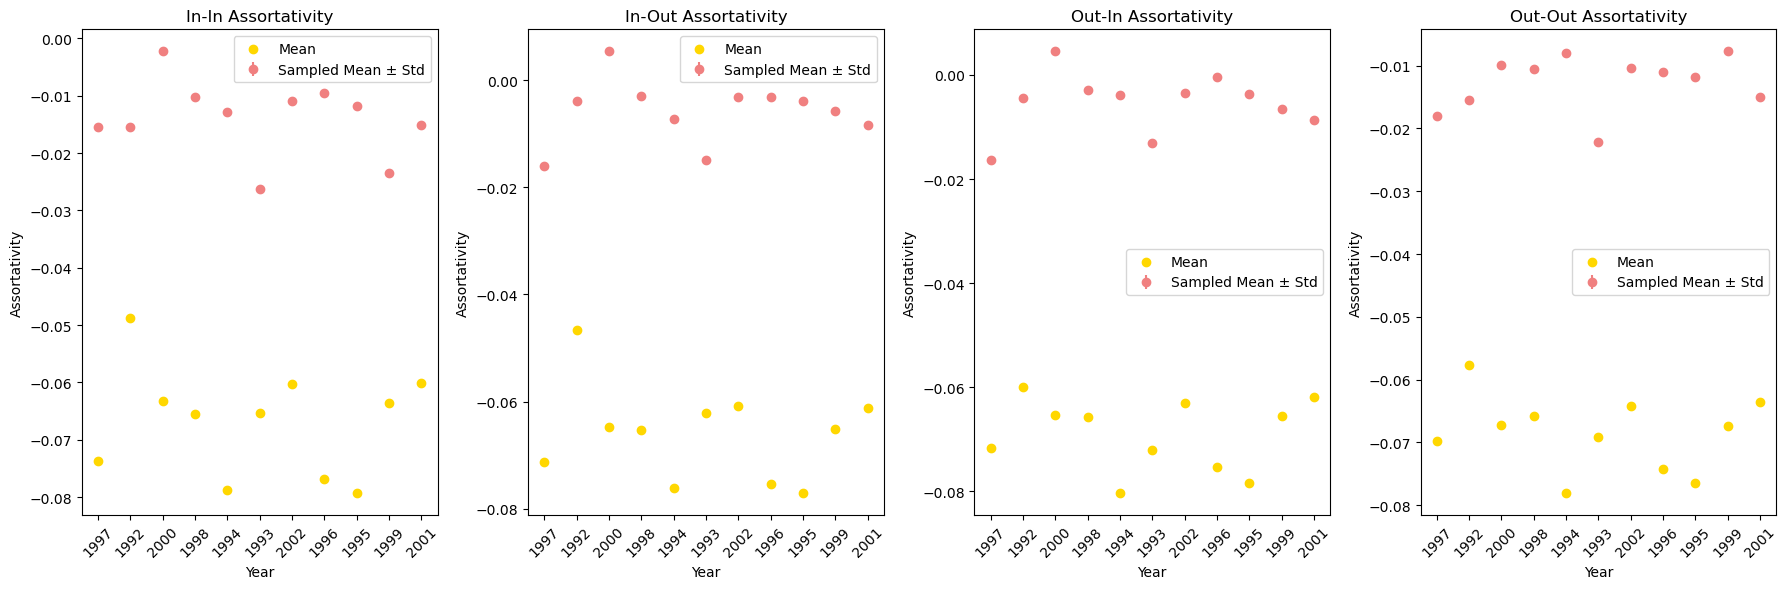

In [388]:
# Years
years = list(nemtropy_directed_results.keys())
x = np.arange(len(years))


# Plotting
plt.figure(figsize=(18, 6))

for i, pair in enumerate(assortativity_pairs):
    plt.subplot(1, len(assortativity_pairs), i + 1)
    sample_means = [nemtropy_directed_results[year]['assortativity_means'][pair] for year in years]
    sample_std = [nemtropy_directed_results[year]['assortativity_stds'][pair] for year in years]

    plt.errorbar(x, sample_means, yerr=sample_std, fmt='o', label='Sampled Mean ± Std', color=COLOR_RED)

    real_mean = [nemtropy_directed_results[year]['assortativity_data'][pair] for year in years]
    plt.scatter(x, real_mean, color=COLOR_YELLOW, label='Mean')


    plt.xticks(x, [year[-4:] for year in years], rotation=45)
    plt.title(f'{pair}')
    plt.xlabel('Year')
    plt.ylabel('Assortativity')
    plt.legend()

plt.tight_layout()
plt.show()

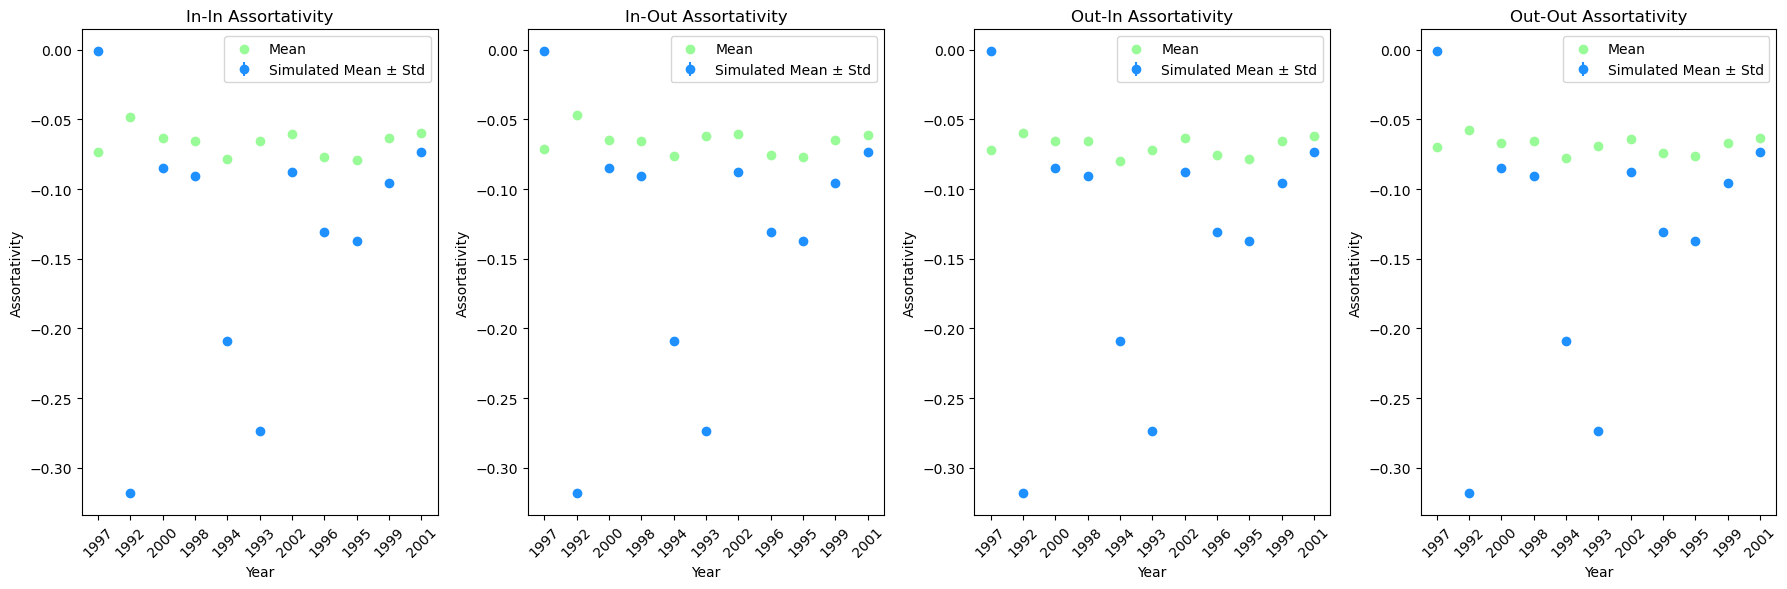

In [389]:
# Years
years = list(nemtropy_undirected_results.keys())
x = np.arange(len(years))

# Plotting
plt.figure(figsize=(18, 6))

for i, pair in enumerate(assortativity_pairs):
    plt.subplot(1, len(assortativity_pairs), i + 1)
    sample_means = [nemtropy_undirected_results[year]['assortativity_means'][pair] for year in years]
    sample_std = [nemtropy_undirected_results[year]['assortativity_stds'][pair] for year in years]

    plt.errorbar(x, sample_means, yerr=sample_std, fmt='o', label='Simulated Mean ± Std', color=COLOR_BLUE)

    # TODO: Can we use the results from the original directed data?
    real_mean = [nemtropy_directed_results[year]['assortativity_data'][pair] for year in years]
    plt.scatter(x, real_mean, color=COLOR_GREEN, label='Mean')

    plt.xticks(x, [year[-4:] for year in years], rotation=45)
    plt.title(f'{pair}')
    plt.xlabel('Year')
    plt.ylabel('Assortativity')
    plt.legend()

plt.tight_layout()
plt.show()

## 5. Write a short paragraph to comment on the interpretation of strength assortativity for this dataset, and about the conclusions you can draw via the inference you made using the ERGM models.

Creating Results:
`jupyter nbconvert Assignment_03.ipynb --to pdf --output Assignment_03_Results.pdf`